# Constant and bichromatic wave boundaries

**What this shows:** wave boundaries defined by a few numbers instead of a dataset:
constant waves, bichromatic wave groups, and no waves at all.

**Prerequisites:** [Tutorial 4: Adding forcing](../tutorial/04_forcing.ipynb).

**You will learn:**

- how to force XBeach with constant wave height, period and direction
- how to add wave groups by setting `Tlong`, and which wave model that needs
- how to switch wave forcing off for tide- or current-only runs
- how the directional grid and spreading settings shape the boundary

**Data used:** none.

## Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from rompy.logging import config as logging_config

logging_config.update(level="WARNING")  # rompy logs every step, show warnings only


def show(boundary):
    """Print the XBeach parameters a wave boundary writes to params.txt."""
    for key, value in boundary.get(destdir=None).items():
        print(f"{key} = {value}")


# The directional grid, relative to the grid x-axis (0 = shore-normal)
DIRECTIONS = {"thetamin": -90.0, "thetamax": 90.0, "dtheta": 10.0}

## 1. Constant waves

`BoundaryParams` corresponds to XBeach's `wbctype = params`. XBeach applies the same
wave height `Hrms`, representative period `Trep` and nautical direction `dir0` for
the whole run. `m` is the power of the cosine directional spreading function, so
larger values give narrower spreading. Use it with the stationary wave model. For
surfbeat runs, use a spectral boundary such as those in
[waves from spectra](waves_from_spectra.ipynb).

In [2]:
from rompy_xbeach.data.boundary import BoundaryParams

show(BoundaryParams(Hrms=1.5, Trep=10.0, dir0=260.0, m=10, **DIRECTIONS))

wbctype = params
thetamin = -90.0
thetamax = 90.0
dtheta = 10.0
Hrms = 1.5
Trep = 10.0
dir0 = 260.0
m = 10


The spreading function is $\cos^m(\theta - \theta_0)$. Here is how `m` changes the
directional spread:

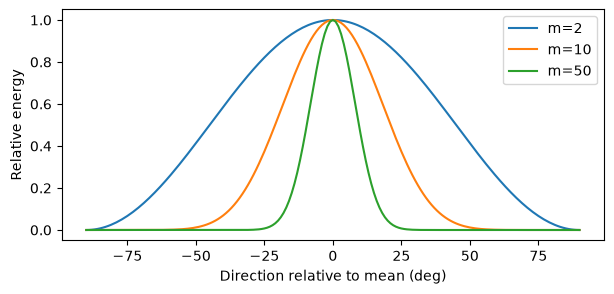

In [3]:
theta = np.linspace(-90, 90, 181)
fig, ax = plt.subplots(figsize=(7, 3))
for m in (2, 10, 50):
    ax.plot(theta, np.cos(np.radians(theta)) ** m, label=f"m={m}")
ax.set(xlabel="Direction relative to mean (deg)", ylabel="Relative energy")
ax.legend()
plt.show()

## 2. Bichromatic wave groups

Setting `Tlong` makes XBeach superimpose two wave trains, which produce regular wave
groups with period `Tlong`. These groups drive long (infragravity) waves, which is
useful for idealised tests of wave-group forcing. Without `Tlong` nothing extra is
written and the waves are constant.

In [4]:
show(BoundaryParams(Hrms=1.0, Trep=10.0, Tlong=80.0, dir0=270.0, m=20, **DIRECTIONS))

wbctype = params
thetamin = -90.0
thetamax = 90.0
dtheta = 10.0
Hrms = 1.0
Trep = 10.0
Tlong = 80.0
dir0 = 270.0
m = 20


XBeach only allows bichromatic waves with the surfbeat wave model. The `Config`
checks this when it is created:

In [5]:
from pydantic import ValidationError
from rompy_xbeach.components.physics import Physics
from rompy_xbeach.components.physics.wavemodel import Stationary
from rompy_xbeach.config import Config, DataInterface
from rompy_xbeach.data.bathy import XBeachBathy
from rompy_xbeach.grid import RegularGrid
from rompy_xbeach.source import SourceGeotiff

try:
    Config(
        grid=RegularGrid(
            ori={"x": 115.594239, "y": -32.641104, "crs": 4326},
            alfa=347.0,
            dx=20.0,
            dy=30.0,
            nx=115,
            ny=110,
            crs=28350,
        ),
        bathy=XBeachBathy(source=SourceGeotiff(filename="../data/bathy.tif")),
        physics=Physics(wavemodel=Stationary()),
        input=DataInterface(wave=BoundaryParams(Hrms=1.0, Trep=10.0, Tlong=80.0)),
    )
except ValidationError as error:
    print(error.errors()[0]["msg"])

Value error, Bichromatic waves (wbctype=params with Tlong) from BoundaryParams cannot be used with the stationary wave model, XBeach requires surfbeat


## 3. No waves: `BoundaryOff`

For tide-only or current-only simulations. The directional grid is still needed
whenever short waves are enabled in `Physics` (the default), so either set it here
or switch short waves off with `Physics(swave=False)`.

In [6]:
from rompy_xbeach.data.boundary import BoundaryOff

show(BoundaryOff(**DIRECTIONS))

wbctype = off
thetamin = -90.0
thetamax = 90.0
dtheta = 10.0


## 4. Common wave boundary settings

All wave boundary classes share settings that control how XBeach applies the
boundary, such as `taper` (spin-up time), `nmax` (maximum ratio of group to wave
speed) and `order`. The
[waves from spectra](waves_from_spectra.ipynb#6.-Common-wave-boundary-settings)
example covers them.

In [7]:
show(BoundaryParams(Hrms=1.5, Trep=10.0, dir0=260.0, taper=300.0, **DIRECTIONS))

wbctype = params
taper = 300.0
thetamin = -90.0
thetamax = 90.0
dtheta = 10.0
Hrms = 1.5
Trep = 10.0
dir0 = 260.0
m = 10


## Summary

| Class | `wbctype` | Use for |
|---|---|---|
| `BoundaryParams` | `params` | Constant conditions, with the stationary model |
| `BoundaryParams` with `Tlong` | `params` | Idealised wave-group forcing, surfbeat only |
| `BoundaryOff` | `off` | Runs without wave forcing |

For time-varying conditions, use the spectral boundaries in
[waves from spectra](waves_from_spectra.ipynb) or
[waves from parameters](waves_from_parameters.ipynb).